# 2 - Features temporais — derivar tempo como input numérico

## Objetivo

Derivar **features temporais** a partir da coluna `Data` para que a GAIN tabular possa capturar sazonalidade e tendência sem precisar tratar a série como sequência regular (impraticável pelos gaps documentados em `Code/2 - EDA/04_temporal.ipynb`).

## Posição na Etapa 2

Notebook **2 de 6**. Entra em cima do `dataset_transformado.parquet` e produz `dataset_com_tempo.parquet`, consumido por `03_encoding.ipynb`.

## Features que serão criadas

| Coluna              | Tipo    | Como calcula                                                            |
| ------------------- | ------- | ----------------------------------------------------------------------- |
| `Ano_int`           | int     | `Data.dt.year` — auditoria/split; não entra como feature numérica.      |
| `ano_norm`          | float   | `(Ano_int − 2012) / 13` — tendência linear em `[0, 1]`.                 |
| `Mes`               | int     | `Data.dt.month` — auxiliar para `Mes_sin/cos`.                          |
| `Mes_sin`           | float   | `sin(2π·Mes/12)` — codificação cíclica.                                 |
| `Mes_cos`           | float   | `cos(2π·Mes/12)` — par de `Mes_sin`.                                    |
| `umido`             | int 0/1 | `1` se `Mes ∈ {11,12,1,2,3}` (regime carioca úmido) senão `0`. Sem one-hot. |
| `dias_desde_inicio` | int     | `(Data − Data.min()).dt.days`.                                          |

## Decisões de desenho recapituladas (de `Code/2 - EDA/resumo.md`)

- **`umido` binária, não 4 estações astronômicas.** O sinal sazonal forte do Rio é o ciclo chuvoso/seco (nov–mar vs abr–out). Binária é mais parcimoniosa e captura o regime climático real.
- **`Mes_sin/cos`** evita o salto numérico dezembro→janeiro: meses adjacentes ficam próximos no plano `(sin, cos)`.
- **`ano_norm` + `dias_desde_inicio`** capturam tendência em duas granularidades (anual e contínua); ambas são fracas (|ρ| < 0,27 em todas as variáveis) mas o custo é baixo.
- **Alerta:** Turbidez (p = 0,067) e Coliformes Termotolerantes (p = 0,22) **não têm sazonalidade detectável** — para essas variáveis o gerador depende de correlações estruturais, não temporais.

## Setup

Imports e caminhos relativos a `Code/3 - Preprocessing/02_features_temporais.ipynb`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

IN_PARQUET  = Path("../../Data/ProcessedData/dataset_transformado.parquet")
OUT_PARQUET = Path("../../Data/ProcessedData/dataset_com_tempo.parquet")
FIG_DIR     = Path("../../Data/Figures/02_Preprocessing/figuras")
FIG_DIR.mkdir(parents=True, exist_ok=True)

ANO_BASE   = 2012   # primeiro ano da série
ANO_SPAN   = 13     # 2012..2025 → divisor de ano_norm
MESES_UMIDO = {11, 12, 1, 2, 3}

## Carregamento

Lê o parquet produzido por `01_transformacoes.ipynb`. Garante que `Data` está em `datetime` (`to_parquet` preserva o tipo, mas verificamos por segurança).

In [2]:
df = pd.read_parquet(IN_PARQUET)
print(f"Shape de entrada: {df.shape}")

assert "Data" in df.columns, "Coluna 'Data' ausente no parquet de entrada."
if not np.issubdtype(df["Data"].dtype, np.datetime64):
    df["Data"] = pd.to_datetime(df["Data"])

print(f"Tipo de Data: {df['Data'].dtype}")
print(f"Intervalo de Data: {df['Data'].min().date()} → {df['Data'].max().date()}")
print(f"NaN em Data: {int(df['Data'].isna().sum())}")

Shape de entrada: (657, 30)
Tipo de Data: datetime64[us]
Intervalo de Data: 2012-01-12 → 2025-11-26
NaN em Data: 0


## Features derivadas

Aplicamos as 7 transformações descritas na tabela do cabeçalho. `Data` é mantida intacta para auditoria; pode ser dropada no split.

In [3]:
df_t = df.copy()

# Bloco anual
df_t["Ano_int"]  = df_t["Data"].dt.year.astype("int64")
df_t["ano_norm"] = (df_t["Ano_int"] - ANO_BASE) / ANO_SPAN

# Bloco mensal
df_t["Mes"]      = df_t["Data"].dt.month.astype("int64")
ang = 2.0 * np.pi * df_t["Mes"] / 12.0
df_t["Mes_sin"]  = np.sin(ang)
df_t["Mes_cos"]  = np.cos(ang)

# Regime climático carioca (binária)
df_t["umido"]    = df_t["Mes"].isin(MESES_UMIDO).astype("int64")

# Tendência contínua
df_t["dias_desde_inicio"] = (df_t["Data"] - df_t["Data"].min()).dt.days.astype("int64")

novas_cols = ["Ano_int", "ano_norm", "Mes", "Mes_sin", "Mes_cos", "umido", "dias_desde_inicio"]
df_t[["Data", *novas_cols]].head(8)

,Data,Ano_int,ano_norm,Mes,Mes_sin,Mes_cos,umido,dias_desde_inicio
0,2012-01-12,2012,0.0,1,0.500000,8.660254e-01,1,0
1,2012-02-09,2012,0.0,2,0.866025,5.000000e-01,1,28
2,2012-03-08,2012,0.0,3,1.000000,6.123234e-17,1,56
3,2012-04-12,2012,0.0,4,0.866025,-5.000000e-01,0,91
4,2012-05-17,2012,0.0,5,0.500000,-8.660254e-01,0,126
5,2012-08-08,2012,0.0,8,-0.866025,-5.000000e-01,0,209
6,2012-10-03,2012,0.0,10,-0.866025,5.000000e-01,0,265
7,2012-11-07,2012,0.0,11,-0.500000,8.660254e-01,1,300


## Sanidade

Verificações essenciais antes de persistir:

1. Nenhuma das novas colunas tem NaN.
2. Amplitudes esperadas: `Mes ∈ [1,12]`, `Mes_sin/cos ∈ [−1,1]`, `umido ∈ {0,1}`, `ano_norm ∈ [0,1]`.
3. Coerência: `Ano_int` coincide com a coluna `Ano` original (se existir), garantindo que não houve inconsistência entre `Data` e `Ano` na consolidação anterior.
4. Distribuição mensal de `umido` confere com o número de meses úmidos (5/12 ≈ 41,7%).

In [4]:
# 1. NaN
n_nan = df_t[novas_cols].isna().sum()
assert (n_nan == 0).all(), f"NaN inesperado:\n{n_nan[n_nan > 0]}"

# 2. Amplitudes
assert df_t["Mes"].between(1, 12).all(),                 "Mes fora de [1,12]."
assert df_t["Mes_sin"].between(-1.0, 1.0).all(),         "Mes_sin fora de [-1,1]."
assert df_t["Mes_cos"].between(-1.0, 1.0).all(),         "Mes_cos fora de [-1,1]."
assert df_t["umido"].isin([0, 1]).all(),                 "umido fora de {0,1}."
assert df_t["ano_norm"].between(0.0, 1.0).all(),         "ano_norm fora de [0,1]."
assert (df_t["dias_desde_inicio"] >= 0).all(),           "dias_desde_inicio negativo."

# 3. Coerência com 'Ano' original (se presente)
if "Ano" in df_t.columns:
    diff = (df_t["Ano"].astype("int64") != df_t["Ano_int"]).sum()
    print(f"Linhas onde 'Ano' (original) difere de 'Ano_int' (derivada de Data): {int(diff)}")
    assert diff == 0, "Inconsistência entre Ano original e Ano_int derivada de Data."

# 4. Proporção de umido
pct_umido = df_t["umido"].mean()
print(f"% de coletas em meses úmidos: {pct_umido:.1%} (referência: 5/12 ≈ 41,7%)")

# Resumo das novas colunas
df_t[novas_cols].describe().T

Linhas onde 'Ano' (original) difere de 'Ano_int' (derivada de Data): 0
% de coletas em meses úmidos: 42.8% (referência: 5/12 ≈ 41,7%)


,count,mean,std,min,25%,50%,75%,max
Ano_int,657.0,2017.480974,4.179292,2012.0,2014.000000,2.016000e+03,2021.000000,2025.0
ano_norm,657.0,0.421613,0.321484,0.0,0.153846,3.076923e-01,0.692308,1.0
Mes,657.0,6.455099,3.451521,1.0,3.000000,6.000000e+00,10.000000,12.0
Mes_sin,657.0,-0.006452,0.725434,-1.0,-0.866025,1.224647e-16,0.500000,1.0
Mes_cos,657.0,0.017475,0.689146,-1.0,-0.500000,6.123234e-17,0.866025,1.0
umido,657.0,0.427702,0.495122,0.0,0.000000,0.000000e+00,1.000000,1.0
dias_desde_inicio,657.0,2170.984779,1529.496434,0.0,900.000000,1.720000e+03,3554.000000,5067.0


## Distribuições das features derivadas

Inspeção visual para detectar qualquer anomalia:

- `Ano_int` e `dias_desde_inicio` refletem o esforço amostral (deve mostrar o vale de 2020 e o pico de 2016, conforme `04_temporal.ipynb`).
- `Mes_sin × Mes_cos` no plano deve formar **círculo unitário** com 12 pontos (1 por mês).
- `umido` é binária; a barra do `1` deve ter ~ 43% das observações (conforme item 4 da sanidade — o desvio do 41,7% teórico reflete o leve viés mensal de coleta documentado em `04_temporal.ipynb`).

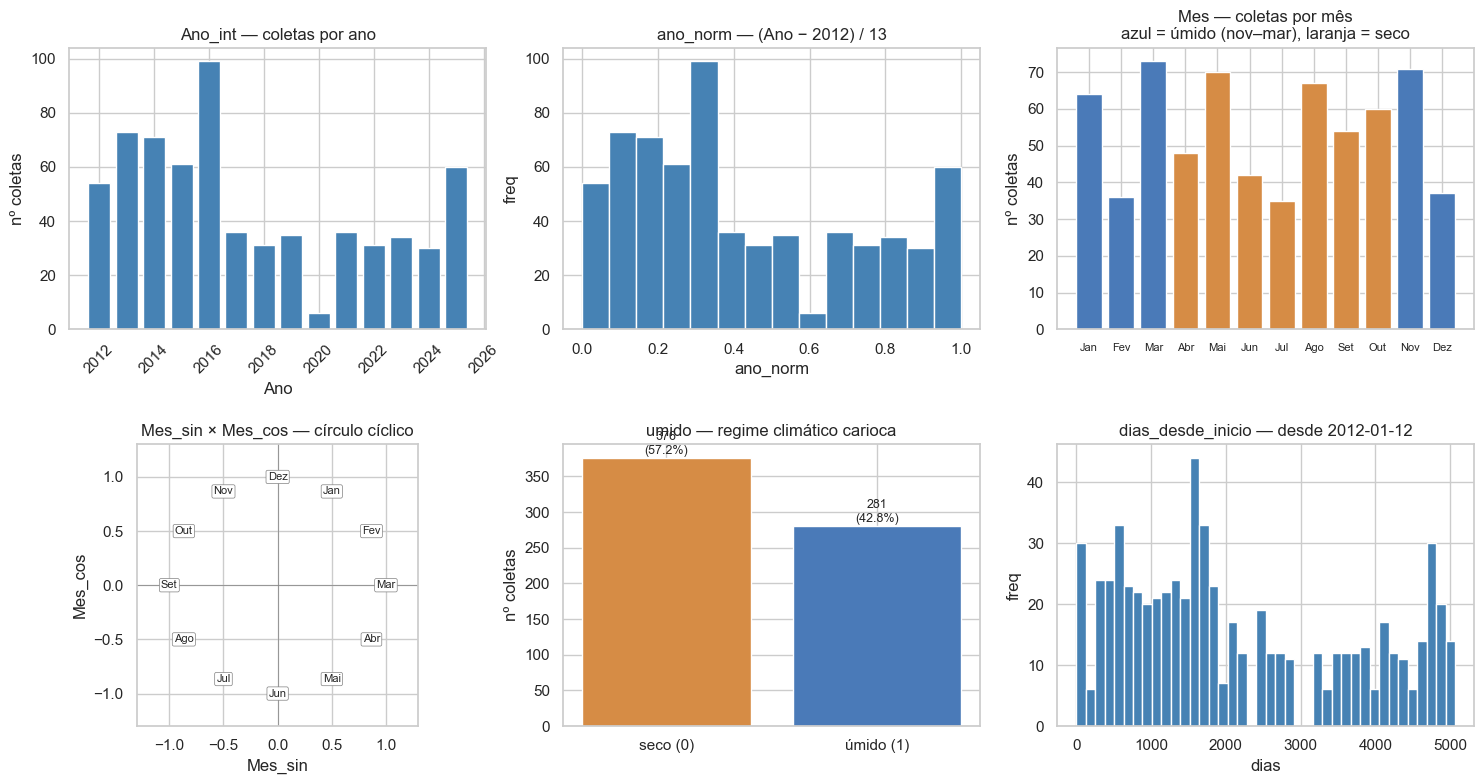

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Linha 1
ax = axes[0, 0]
ax.bar(df_t["Ano_int"].value_counts().sort_index().index,
       df_t["Ano_int"].value_counts().sort_index().values,
       color="steelblue", edgecolor="white")
ax.set_title("Ano_int — coletas por ano")
ax.set_xlabel("Ano"); ax.set_ylabel("nº coletas")
ax.tick_params(axis="x", rotation=45)

ax = axes[0, 1]
ax.hist(df_t["ano_norm"], bins=14, color="steelblue", edgecolor="white")
ax.set_title("ano_norm — (Ano − 2012) / 13")
ax.set_xlabel("ano_norm"); ax.set_ylabel("freq")

ax = axes[0, 2]
meses_lbl = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
             "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
cores = ["#4a7ab8" if m in MESES_UMIDO else "#d68c45" for m in range(1, 13)]
contagens = df_t["Mes"].value_counts().reindex(range(1, 13), fill_value=0)
ax.bar(range(1, 13), contagens.values, color=cores, edgecolor="white")
ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses_lbl, fontsize=8)
ax.set_title("Mes — coletas por mês\nazul = úmido (nov–mar), laranja = seco")
ax.set_ylabel("nº coletas")

# Linha 2
ax = axes[1, 0]
ax.scatter(df_t["Mes_sin"], df_t["Mes_cos"], s=18, alpha=0.4, color="steelblue")
for m in range(1, 13):
    ang_m = 2 * np.pi * m / 12
    ax.annotate(meses_lbl[m - 1], (np.sin(ang_m), np.cos(ang_m)),
                fontsize=8, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="gray", lw=0.5))
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_title("Mes_sin × Mes_cos — círculo cíclico")
ax.set_xlabel("Mes_sin"); ax.set_ylabel("Mes_cos")

ax = axes[1, 1]
contagem_umido = df_t["umido"].value_counts().sort_index()
ax.bar(["seco (0)", "úmido (1)"], contagem_umido.values,
       color=["#d68c45", "#4a7ab8"], edgecolor="white")
for i, v in enumerate(contagem_umido.values):
    ax.text(i, v + 5, f"{v}\n({v/len(df_t):.1%})", ha="center", fontsize=9)
ax.set_title("umido — regime climático carioca")
ax.set_ylabel("nº coletas")

ax = axes[1, 2]
ax.hist(df_t["dias_desde_inicio"], bins=40, color="steelblue", edgecolor="white")
ax.set_title("dias_desde_inicio — desde 2012-01-12")
ax.set_xlabel("dias"); ax.set_ylabel("freq")

plt.tight_layout()
fig.savefig(FIG_DIR / "tempo_features_dist.png", dpi=150)
plt.show()

**Como interpretar:**

- O painel `Ano_int` deve reproduzir o perfil amostral conhecido (pico ~2016, vale 2020 por COVID, retomada 2025).
- O painel `Mes_sin × Mes_cos` confirma que a codificação cíclica está correta: os 12 pontos formam um círculo unitário, dezembro e janeiro são vizinhos no plano.
- A barra `umido = 1` deve estar entre 40% e 45% — coerente com o resumo do `04_temporal.ipynb` que reportou 43% das coletas em meses úmidos.
- `dias_desde_inicio` é uniforme ao longo do período, com vale visível no centro (2020).

## Persistência

Saída em `Data/ProcessedData/dataset_com_tempo.parquet`. As 7 novas colunas se somam às do input — o número de linhas é preservado.

In [6]:
cols_in  = set(df.columns)
cols_out = set(df_t.columns)
novas    = cols_out - cols_in

print(f"Colunas adicionadas ({len(novas)}): {sorted(novas)}")
assert novas == set(novas_cols), "Conjunto de colunas adicionadas difere do esperado."
assert len(df_t) == len(df), "Número de linhas mudou."

df_t.to_parquet(OUT_PARQUET, index=False)
print(f"\nSalvo: {OUT_PARQUET} ({OUT_PARQUET.stat().st_size} bytes)")
print(f"Shape final: {df_t.shape} (entrada: {df.shape})")

Colunas adicionadas (7): ['Ano_int', 'Mes', 'Mes_cos', 'Mes_sin', 'ano_norm', 'dias_desde_inicio', 'umido']

Salvo: ..\..\Data\ProcessedData\dataset_com_tempo.parquet (49386 bytes)
Shape final: (657, 37) (entrada: (657, 30))


## Síntese final

- 7 colunas adicionadas: `Ano_int`, `ano_norm`, `Mes`, `Mes_sin`, `Mes_cos`, `umido`, `dias_desde_inicio`.
- Todas as sanidades passaram: sem NaN, amplitudes corretas, `Ano_int` coincide com `Ano` original.
- `umido` ficou em ~43% (consistente com o esforço amostral mensal observado em `04_temporal.ipynb`).
- `Data` original preservada para auditoria; pode ser dropada em `05_split.ipynb`.

### Próximo notebook

`03_encoding.ipynb` — one-hot de `Codigo Local` (8 estações) e de `<Var>_LD` apenas para as 6 variáveis com `decisao ∈ {moderada, alta}`. `umido` passa direto (já binária).